In [2]:
""" 
PROGRAM :  diagnostics_basics.ipynb 

reads in intpp assimilation runs, historical simulations 
and raw forecasts under CMIP6 emissions 
to produce some basic diagnostics

STATUS  : Complete 
COMMENTS: (1) No adjusted forecast shown her
"""

' \nPROGRAM :  diagnostics_basics.ipynb \n\nreads in intpp assimilation runs, historical simulations \nand raw forecasts under CMIP6 emissions \nto produce some basic diagnostics\n\nSTATUS  : Complete \nCOMMENTS: (1) No adjusted forecast shown her\n'

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

import configs
from prepare import (prepare_data_for_analysis, 
                     experiment_finder,
                     get_glodap_clim)

from modules.plotting.module_plot_maps import *


In [3]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx

### Configs

In [9]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'


assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = [ 'dissic'] #,'talk','dissic', 'no3',  'silicate', 'po4']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']
obs_source = {'dissic' : 'GLODAP'} 

 ## this could be a dictionary for each variable as they might have different sources.
decompose_spco2: bool = False
vars_to_det: list[str] =  None #['spco2']


### Data Loading

In [10]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            verbose = True)

dict_clim_data = get_glodap_clim(dict_em_data, model_levels)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/dissic/observation/GLODAP

model directories: 

dissic assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/dissic/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/dissic/assimilation/CanESM5-CanOE_1
dissic historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/dissic/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/dissic/historical/CanESM5-CanOE
loading CanESM5 dissic assimilation...
done.
loading CanESM5-CanOE_1 dissic assimilation...
done.
loading CanESM5 dissic historical...
done.
loading CanESM5-CanOE dissic historical...
done.
loading dissic
done.


In [11]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [12]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_clim_data:
        for exp in dict_clim_data[var]:
            print(f'{var} {exp}')
            display(dict_clim_data[var][exp].data)




### Plots

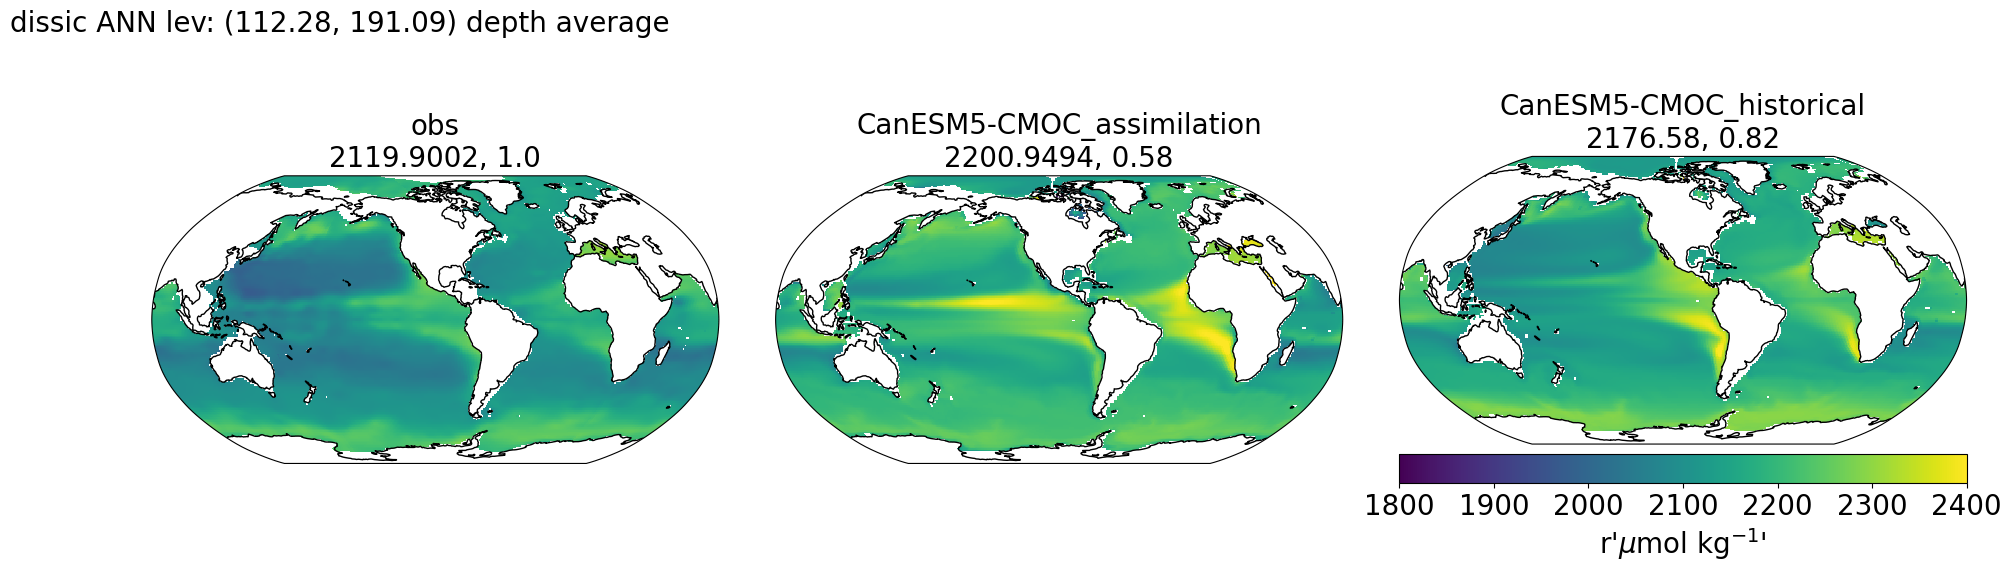

In [14]:
var = 'dissic'

model_experiment = ['observation', 'CanESM5 assimilation' , 'CanESM5 historical']

figsize = (20,20)

central_longitude = 260
vmax=2400
vmin=1800

datadict = dict_clim_data[var]
ds_list = experiment_finder(datadict, model_experiment)

plot_composites(ds_list,
                    datadict,
                    figsize=figsize,                    
                    central_longitude=central_longitude,
                    vmax=vmax,
                    vmin=vmin,
                    cmap = 'viridis',
                    depth_range=(100,200),
                    cbar_label= units[var],  
                    var_name = var)
